In [2]:
import pandas as pd

df = pd.read_csv("/college_student_placement_dataset.csv")

print(df.columns)
print(df.shape)
df.head()



Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')
(10000, 10)


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [3]:
df = df.drop("College_ID", axis=1)

df["Internship_Experience"] = df["Internship_Experience"].map({"Yes": 1, "No": 0})
df["Placement"] = df["Placement"].map({"Yes": 1, "No": 0})

df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0


In [4]:
X = df.drop("Placement", axis=1)
y = df["Placement"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 8)
Target shape: (10000,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000, 8)
Test size: (2000, 8)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1) Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# 2) Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

# 3) Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Accuracy - Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Accuracy - Decision Tree:", accuracy_score(y_test, pred_dt))
print("Accuracy - Random Forest:", accuracy_score(y_test, pred_rf))

Accuracy - Logistic Regression: 0.9035
Accuracy - Decision Tree: 1.0
Accuracy - Random Forest: 1.0


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Logistic Regression ===")
print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

print("\n=== Decision Tree ===")
print(confusion_matrix(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

print("\n=== Random Forest ===")
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

=== Logistic Regression ===
[[1609   65]
 [ 128  198]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.75      0.61      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000


=== Decision Tree ===
[[1674    0]
 [   0  326]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


=== Random Forest ===
[[1674    0]
 [   0  326]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy               

In [8]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance

,0
Communication_Skills,0.297839
IQ,0.248744
Projects_Completed,0.178032
CGPA,0.151212
Prev_Sem_Result,0.099674
Extra_Curricular_Score,0.011020
Academic_Performance,0.010615
Internship_Experience,0.002864


In [9]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X, y, cv=5)

print("Random Forest Cross Validation Scores:", rf_cv)
print("Mean CV Accuracy:", rf_cv.mean())

Random Forest Cross Validation Scores: [0.9995 0.9995 1.     0.9995 0.9995]
Mean CV Accuracy: 0.9996


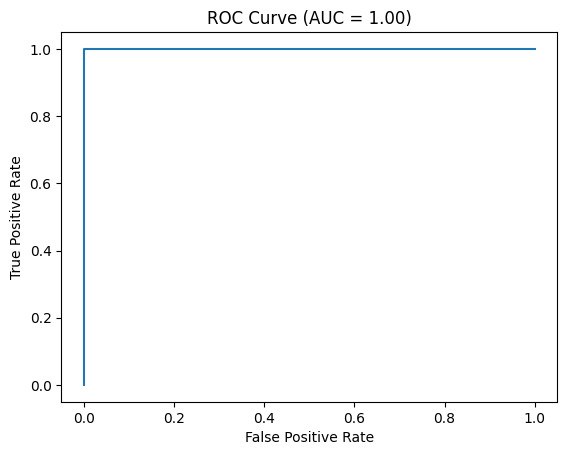

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

rf_probs = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
auc_score = roc_auc_score(y_test, rf_probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()

In [11]:
import numpy as np

# Make a copy so original dataset remains safe
df_noisy = df.copy()

# Percentage of noise
noise_percent = 0.02  # 5%

# Number of rows to flip
n_flip = int(noise_percent * len(df_noisy))

# Randomly select indices to flip
np.random.seed(42)
flip_indices = np.random.choice(df_noisy.index, size=n_flip, replace=False)

# Flip Placement labels (1->0, 0->1)
df_noisy.loc[flip_indices, "Placement"] = 1 - df_noisy.loc[flip_indices, "Placement"]

print("Number of flipped labels:", n_flip)

Number of flipped labels: 200


In [12]:
X = df_noisy.drop("Placement", axis=1)
y = df_noisy["Placement"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Accuracy - Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Accuracy - Decision Tree:", accuracy_score(y_test, pred_dt))
print("Accuracy - Random Forest:", accuracy_score(y_test, pred_rf))

Accuracy - Logistic Regression: 0.8235
Accuracy - Decision Tree: 0.9
Accuracy - Random Forest: 0.9


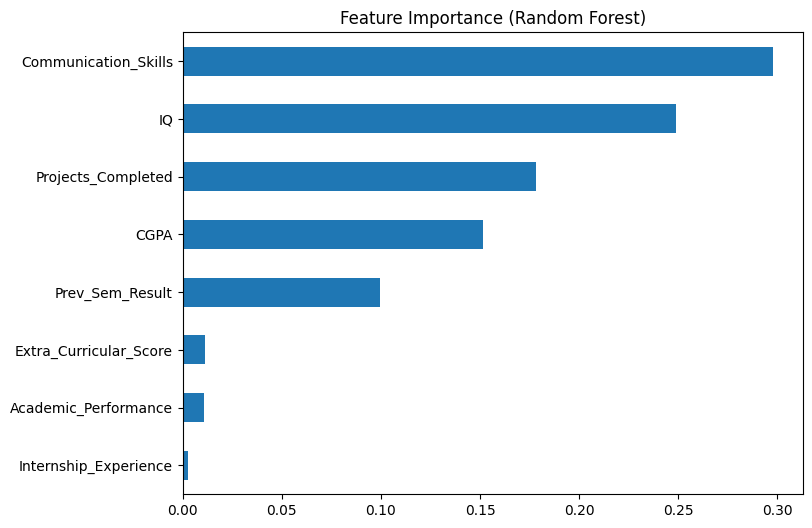

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()

In [15]:
def predict_student(data):
    import pandas as pd

    # Convert input list into DataFrame with correct column names
    input_df = pd.DataFrame([data], columns=X.columns)

    prediction = rf.predict(input_df)
    probability = rf.predict_proba(input_df)[0][1]

    if prediction[0] == 1:
        print(f"Predicted: Placed (Probability: {probability:.2f})")
    else:
        print(f"Predicted: Not Placed (Probability: {probability:.2f})")

In [16]:
predict_student([110, 8.5, 8.7, 9, 1, 8, 9, 4])

Predicted: Placed (Probability: 0.96)
